## Polynomial Regression on Boston Housing Dataset

**In this notebook we do a comparative study of Linear Regression and Polynomial Regression accuracy on the Boston Housing Dataset**

**Cada registro (cada fila) del Boston Housing Dataset representa un distrito censal (census tract) de la ciudad de Boston**

This data was originally a part of UCI Machine Learning Repository and has been removed now. This data also ships with the scikit-learn library. 
There are 506 samples and 13 feature variables in this data-set. The objective is to predict the value of prices of the house using the given features.

The description of all the features is given below:

  **CRIM**: Per capita crime rate by town

  **ZN**: Proportion of residential land zoned for lots over 25,000 sq. ft

  **INDUS**: Proportion of non-retail business acres per town

  **CHAS**: Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)

  **NOX**: Nitric oxide concentration (parts per 10 million)

  **RM**: Average number of rooms per dwelling

  **AGE**: Proportion of owner-occupied units built prior to 1940

  **DIS**: Weighted distances to five Boston employment centers

  **RAD**: Index of accessibility to radial highways

  **TAX**: Full-value property tax rate per $10,000

  **B**: 1000(Bk - 0.63)², where Bk is the proportion of [people of African American descent] by town

  **LSTAT**: Percentage of lower status of the population

  **MEDV**: Median value of owner-occupied homes in $1000s

## EXPLICACIÓN VARIABLES

1. CRIM

Traducción: Tasa de criminalidad per cápita por ciudad/población.
Explicación: Representa cuántos crímenes ocurren, en promedio, por persona en cada localidad. Indica la seguridad del área.

2. ZN

Traducción: Proporción de terreno residencial zonificado para lotes de más de 25,000 pies².
Explicación: Es el porcentaje del suelo destinado a viviendas amplias (parcelas grandes). Cuanto mayor sea este valor, más “residencial de lujo” es la zona.

3. INDUS

Traducción: Proporción de acres dedicados a negocios no minoristas (industrial) por ciudad.
Explicación: Indica qué porcentaje de la ciudad está ocupado por áreas industriales (fábricas, almacenes, etc.). Valores altos suelen relacionarse con mayor contaminación o ruido.

4. CHAS

Traducción: Variable ficticia del Río Charles (=1 si el distrito limita con el río; 0 si no).
Explicación: Mide si la zona tiene acceso directo al río Charles, algo que puede aumentar el valor de las viviendas.

5. NOX

Traducción: Concentración de óxidos de nitrógeno (partes por cada 10 millones).
Explicación: Contaminante atmosférico. Valores altos indican peor calidad del aire.

6. RM

Traducción: Número promedio de habitaciones por vivienda.
Explicación: Cuantas más habitaciones, típicamente mayor tamaño y valor de la vivienda.

7. AGE

Traducción: Proporción de viviendas ocupadas por sus dueños que fueron construidas antes de 1940.
Explicación: Indica qué tan antiguas son las casas. Un valor alto implica una zona con viviendas viejas.

8. DIS

Traducción: Distancias ponderadas a cinco centros de empleo en Boston.
Explicación: Cuanto mayor sea el valor, más lejos está el área de los principales centros de trabajo.

9. RAD

Traducción: Índice de accesibilidad a autopistas radiales.
Explicación: Mide qué tan fácil es acceder a las autopistas desde esa zona. Valores altos indican muy buena conexión vial.

10. TAX

Traducción: Tasa de impuestos íntegros a la propiedad por cada $10,000 de valor.
Explicación: Impuesto anual que deben pagar las propiedades. Puede reflejar la calidad de los servicios locales.

11. B

Traducción: 1000(Bk − 0.63)², donde Bk es la proporción de personas afroamericanas en la ciudad.
Explicación: Es una variable histórica problemática creada para medir composición demográfica. Hoy se considera inapropiada, pero se mantiene en el dataset por motivos académicos.

12. LSTAT

Traducción: Porcentaje de población de bajo estatus socioeconómico.
Explicación: Indica la proporción de hogares con nivel socioeconómico bajo. Valor alto suele asociarse a precios de vivienda más bajos.

13. MEDV

Traducción: Valor mediano de las viviendas ocupadas por sus dueños (en miles de dólares).
Explicación: Es la variable objetivo en muchos modelos predictores del dataset. Por ejemplo, un MEDV = 22 significa $22,000 (en valores históricos).
  
  
  



**Import the required Libraries**

In [206]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

**Load the data into pandas dataframe . Load the Boston Housing DataSet from data/boston_house_prices.csv**

In [207]:
df_boston = pd.read_csv("data/boston_house_prices.csv", sep=",")
df_boston

,506,13,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13
0,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
1,0.00632,18,2.31,0,0.538,6.575,65.2,4.09,1,296,15.3,396.9,4.98,24
2,0.02731,0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.9,9.14,21.6
3,0.02729,0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
4,0.03237,0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
502,0.06263,0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21,391.99,9.67,22.4
503,0.04527,0,11.93,0,0.573,6.12,76.7,2.2875,1,273,21,396.9,9.08,20.6
504,0.06076,0,11.93,0,0.573,6.976,91,2.1675,1,273,21,396.9,5.64,23.9
505,0.10959,0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21,393.45,6.48,22


In [208]:
df_boston.columns = df_boston.iloc[0]
df_boston = df_boston[1:].reset_index(drop=True)
df_boston.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18,2.31,0,0.538,6.575,65.2,4.09,1,296,15.3,396.9,4.98,24
1,0.02731,0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.9,9.14,21.6
2,0.02729,0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.9,5.33,36.2


In [209]:
df_boston.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   CRIM     506 non-null    object
 1   ZN       506 non-null    object
 2   INDUS    506 non-null    object
 3   CHAS     506 non-null    object
 4   NOX      506 non-null    object
 5   RM       506 non-null    object
 6   AGE      506 non-null    object
 7   DIS      506 non-null    object
 8   RAD      506 non-null    object
 9   TAX      506 non-null    object
 10  PTRATIO  506 non-null    object
 11  B        506 non-null    object
 12  LSTAT    506 non-null    object
 13  MEDV     506 non-null    object
dtypes: object(14)
memory usage: 55.5+ KB


In [210]:
df_boston.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506,506,506,506,506,506,506,506,506,506,506,506,506,506
unique,504,26,76,2,81,446,356,412,9,66,46,357,455,229
top,0.01501,0,18.1,0,0.538,6.229,100,3.4952,24,666,20.2,396.9,6.36,50
freq,2,372,132,471,23,3,43,5,132,132,140,121,3,16


**Data preprocessing**

Check for missing values in all the columns

In [211]:
df_boston.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   CRIM     506 non-null    object
 1   ZN       506 non-null    object
 2   INDUS    506 non-null    object
 3   CHAS     506 non-null    object
 4   NOX      506 non-null    object
 5   RM       506 non-null    object
 6   AGE      506 non-null    object
 7   DIS      506 non-null    object
 8   RAD      506 non-null    object
 9   TAX      506 non-null    object
 10  PTRATIO  506 non-null    object
 11  B        506 non-null    object
 12  LSTAT    506 non-null    object
 13  MEDV     506 non-null    object
dtypes: object(14)
memory usage: 55.5+ KB


In [212]:
df_boston.isnull().sum()

0
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

In [213]:
df_boston = df_boston.apply(pd.to_numeric, errors='coerce')
df_boston.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [214]:
df_boston.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


**Data Visualization**

In [215]:
df_boston.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


**Correlation matrix**

Analyze the correlation matrix. Plot a heatmap

* From correlation plot: which are the columns that are more correlated with **MEDV**

RM: Número promedio de habitaciones por vivienda.

LSTAT: Porcentaje de población de bajo estatus socioeconómico.

* There are two features highly correlated. Identify them and drop one of them in order to avoid multi-colinearity

RAD: Índice de accesibilidad a autopistas radiales.

TAX: Tasa de impuestos íntegros a la propiedad por cada $10,000 de valor.


In [216]:
df_boston.corr()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,,,,,,,,,,,,,,
CRIM,1.000000,-0.200469,0.406583,-0.055892,0.420972,-0.219247,0.352734,-0.379670,0.625505,0.582764,0.289946,-0.385064,0.455621,-0.388305
ZN,-0.200469,1.000000,-0.533828,-0.042697,-0.516604,0.311991,-0.569537,0.664408,-0.311948,-0.314563,-0.391679,0.175520,-0.412995,0.360445
INDUS,0.406583,-0.533828,1.000000,0.062938,0.763651,-0.391676,0.644779,-0.708027,0.595129,0.720760,0.383248,-0.356977,0.603800,-0.483725
CHAS,-0.055892,-0.042697,0.062938,1.000000,0.091203,0.091251,0.086518,-0.099176,-0.007368,-0.035587,-0.121515,0.048788,-0.053929,0.175260
NOX,0.420972,-0.516604,0.763651,0.091203,1.000000,-0.302188,0.731470,-0.769230,0.611441,0.668023,0.188933,-0.380051,0.590879,-0.427321
RM,-0.219247,0.311991,-0.391676,0.091251,-0.302188,1.000000,-0.240265,0.205246,-0.209847,-0.292048,-0.355501,0.128069,-0.613808,0.695360
AGE,0.352734,-0.569537,0.644779,0.086518,0.731470,-0.240265,1.000000,-0.747881,0.456022,0.506456,0.261515,-0.273534,0.602339,-0.376955
DIS,-0.379670,0.664408,-0.708027,-0.099176,-0.769230,0.205246,-0.747881,1.000000,-0.494588,-0.534432,-0.232471,0.291512,-0.496996,0.249929
RAD,0.625505,-0.311948,0.595129,-0.007368,0.611441,-0.209847,0.456022,-0.494588,1.000000,0.910228,0.464741,-0.444413,0.488676,-0.381626


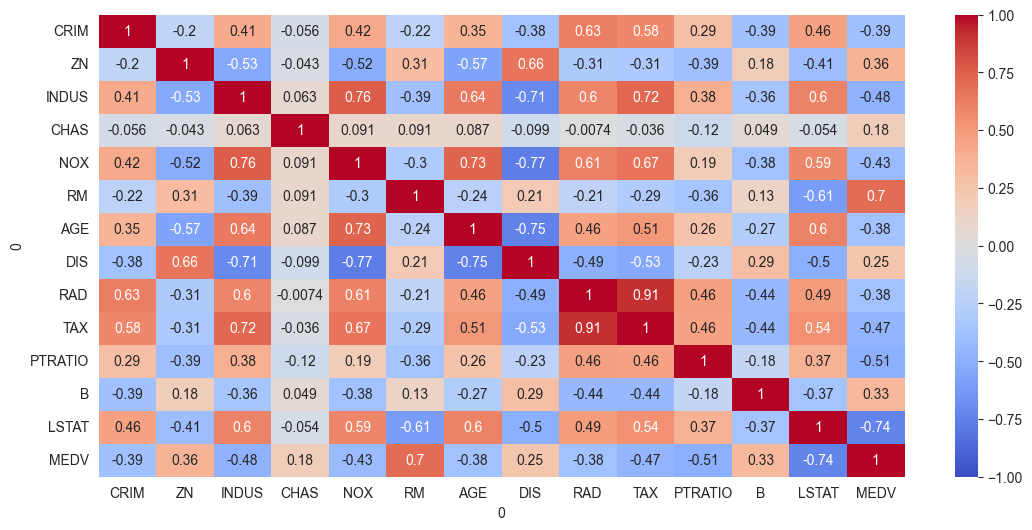

In [217]:
plt.figure(figsize=(13, 6)) 
sns.heatmap(df_boston.corr(numeric_only=True), annot=True, vmin=-1, cmap='coolwarm');

In [218]:
df_boston.drop("RAD", axis=1, inplace=True)

In [219]:
df_boston

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,222,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,273,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,273,21.0,393.45,6.48,22.0


### Draw 2 scatter plots to see the relationship between **MEDV** and **LSTAT** and **RM**

GRÁFICO MEDV - LSTAT

Text(0, 0.5, 'MEDV')

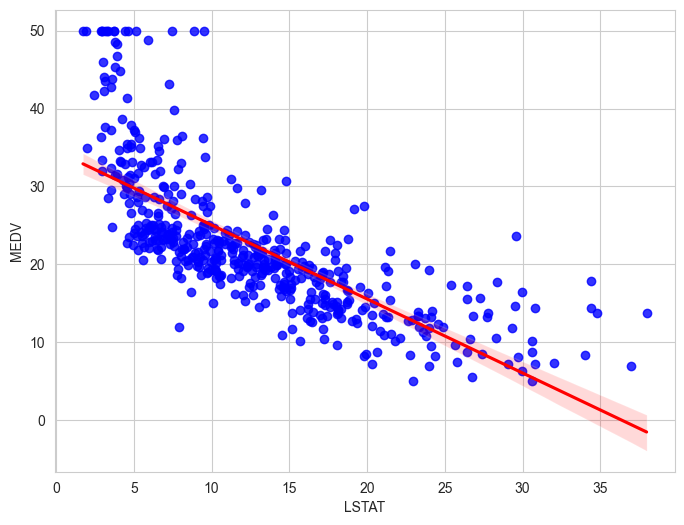

In [220]:
plt.figure(figsize=(8, 6))
sns.regplot(x=df_boston["LSTAT"], y=df_boston["MEDV"], scatter_kws={'color':'blue'}, line_kws={'color':'red'})
plt.xlabel("LSTAT")
plt.ylabel("MEDV")

Text(0, 0.5, 'MEDV')

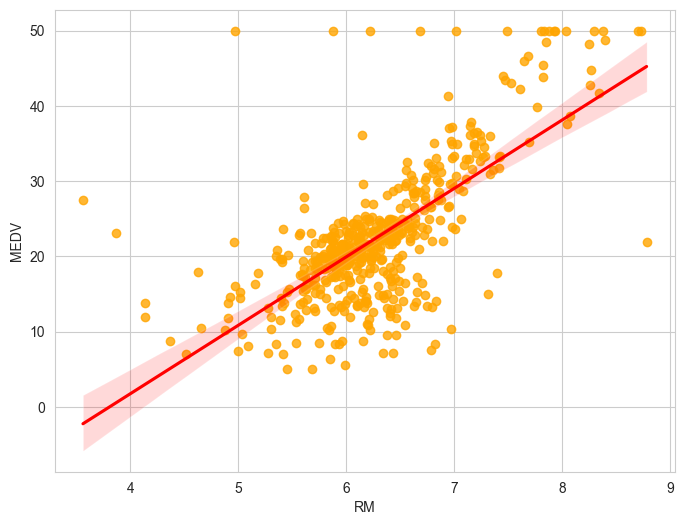

In [221]:
plt.figure(figsize=(8, 6))
sns.regplot(x=df_boston["RM"], y=df_boston["MEDV"], scatter_kws={'color':'orange'}, line_kws={'color':'red'})
plt.xlabel("RM")
plt.ylabel("MEDV")

**Prepare the data for training**
Create a dataframe X including **LSTAT** and **RM** columns.
Y should be a pandas series including target values **'MEDV'**


In [222]:
X = df_boston[["LSTAT", "RM"]]
X

,LSTAT,RM
0,4.98,6.575
1,9.14,6.421
2,4.03,7.185
3,2.94,6.998
4,5.33,7.147
...,...,...
501,9.67,6.593
502,9.08,6.120
503,5.64,6.976
504,6.48,6.794


In [223]:
y = df_boston["MEDV"]
y

0      24.0
1      21.6
2      34.7
3      33.4
4      36.2
       ... 
501    22.4
502    20.6
503    23.9
504    22.0
505    11.9
Name: MEDV, Length: 506, dtype: float64

**Split the data into training and testing sets**

Splits the training and test data set in 80% : 20%. Assign random_state to any value. This ensures consistency. Print the sahes of the resulting objects

In [224]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state=42)

print("Total features shape:", X.shape)
print("Train features shape:", X_train.shape)
print("Train target shape:", y_train.shape)
print("Total features shape:", y.shape)
print("Test features shape:", y_train.shape)
print("Test target shape:", y_test.shape)

Total features shape: (506, 2)
Train features shape: (404, 2)
Train target shape: (404,)
Total features shape: (506,)
Test features shape: (404,)
Test target shape: (102,)


# **Linear Regression**

Build a linear regression model with sklearn LinearRegression.
We'll use Mean Squared error and R2 score to evaluate our model, so be sure to make the needed imports.

Import the necessary functions and train a LinearRegression model

In [225]:
from sklearn.linear_model import LinearRegression
from sklearn import metrics

boston_model = LinearRegression()

**Evaluate the model performance in the training and testing sets**

In [226]:
boston_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [227]:
y_pred = boston_model.predict(X_test)
print(y_pred)

[25.50510964 30.8592405  17.42725985 25.81325491 19.64929972 22.90317032
 16.88571841 14.61917747 22.06066668 20.03326882 17.34725148 18.15555053
 -2.53419257 22.41228621 19.92807359 26.93027912 17.16881388  3.46139894
 37.31795503 18.49325989 26.09287374 27.0359285  13.08646469 26.07395803
 19.05197872 14.34439003 22.50507619 21.09395936 17.80756143 18.90537548
 17.3189494  26.72355799 27.62430957 19.01752219 15.4809415  17.37191951
 32.8765884  22.03500171 20.02675295 25.5193256  12.24468569 28.82657024
 38.2438306  18.45117927 25.65604941 16.5588818  15.7090024  26.97797141
 19.55868547 28.94200451 20.60534552 31.33646277 17.88508649 28.36639373
 34.9844153  23.96269158 19.65312104 31.54864539 24.99070281 15.11477808
 27.10508448 32.73300584 29.58795549 18.58249363 28.64129064 10.75991895
 20.69510169 26.34948505 29.46875554 16.79445551 18.83002976 28.15270076
 13.10437033 25.07663224 23.21876915  6.6118755  22.06337978 36.66642406
 18.59482469 10.58587713 22.76126683 10.15832067 22

In [228]:
df_final = pd.DataFrame(y_test.values, columns = ["Target"])
df_final["pred"] = y_pred
df_final

,Target,pred
0,23.6,25.505110
1,32.4,30.859241
2,13.6,17.427260
3,22.8,25.813255
4,16.1,19.649300
...,...,...
97,17.9,-0.287676
98,9.6,20.052227
99,17.2,19.118366
100,22.5,20.897461


In [229]:
print('MAE:', metrics.mean_absolute_error(y_test, y_pred))
print('MSE:', metrics.mean_squared_error(y_test, y_pred))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
print('MAPE:', metrics.mean_absolute_percentage_error(y_test, y_pred))
print("r2_score train", boston_model.score(X_train, y_train))
print("r2_score test",boston_model.score(X_test, y_test))

MAE: 3.898759721382358
MSE: 31.243290601783627
RMSE: 5.589569804715174
MAPE: 0.20743640153704945
r2_score train 0.6501592679428922
r2_score test 0.5739577415025858


**Lets see the model performance visually. Let's plot y_test vs y_pred**

Plotting the y_test vs y_pred. Ideally should have been a straight line

Text(0, 0.5, 'Valores de la predicción (y_pred)')

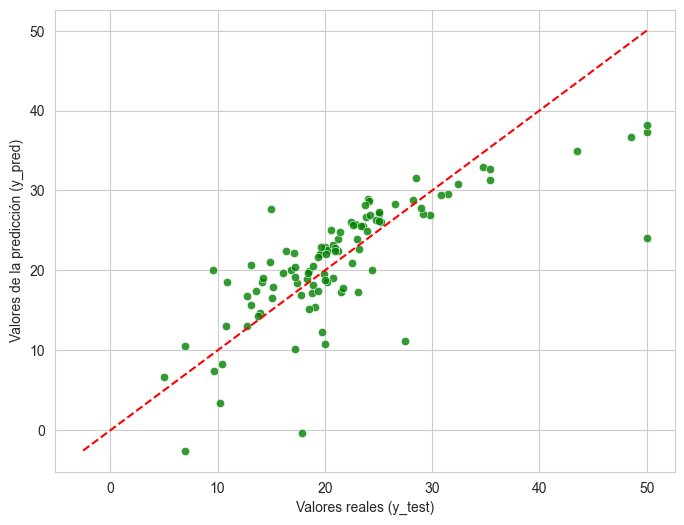

In [230]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x = y_test, y= y_pred, color= "green", alpha= 0.8)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--')
plt.xlabel("Valores reales (y_test)")
plt.ylabel("Valores de la predicción (y_pred)")

# **Polynomial Regression**

We can see that **LSTAT** doesn't vary exactly in a linear way. Let's apply the Polynomial Regression with **degree 2** and test. 

To generate the higher order degrees, we use PolyniomialFeatures class from sklearn library. 

In [199]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, r2_score

In [232]:
poly_feats = PolynomialFeatures(degree = 2)
poly_feats.fit(X)
X_poly = poly_feats.transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_poly,y, test_size = 0.2, random_state=42)

boston_model_poly = LinearRegression()
boston_model_poly.fit(X_train, y_train)

predictions = boston_model_poly.predict(X_test)

print("MAE:", mean_absolute_error(y_test, predictions))
print("MSE:", mean_squared_error(y_test, predictions))
print("RMSE:", np.sqrt(mean_squared_error(y_test, predictions)))
print("MAPE:", mean_absolute_percentage_error(y_test, predictions))
print("r2_score train", boston_model_poly.score(X_train, y_train))
print("r2_score test", boston_model_poly.score(X_test, y_test))

MAE: 2.883346947360541
MSE: 18.433777739111076
RMSE: 4.293457550635743
MAPE: 0.15958620425165262
r2_score train 0.7576154344716141
r2_score test 0.7486318454509433


**Did the model improve using the Polynomial model?**

Sí, lo mejora bastante:

**EVALUACIÓN DEL MODELO DE REGRESIÓN LINEAL**

MAE: 3.898759721382358

MSE: 31.243290601783627

RMSE: 5.589569804715174

MAPE: 0.20743640153704945

r2_score train 0.6501592679428922

r2_score test 0.5739577415025858

**EVALUACIÓN DEL MODELO POLINÓMICO 2 GRADOS**

MAE: 2.883346947360541

MSE: 18.433777739111076

RMSE: 4.293457550635743

MAPE: 0.15958620425165262

r2_score train 0.7576154344716141

r2_score test 0.7486318454509433

**Did the model improve using the Polynomial model with degree 3? Or more?**

No, el modelo no mejora al aumentar los grados del polinomio, sino que se empeora debido al overfitting 

# 📊 Evaluación de Modelos Polinómicos  
## ¿El modelo mejora con el polinómico de grado 2?

---

## ✅ Conclusión Principal

El **mejor modelo es el polinómico de grado = 2**, porque:

- Presenta los **errores más bajos** (MAE, MSE, RMSE, MAPE).
- Tiene un **R² en test = 0.748**, indicando buena capacidad de generalización.
- Su **R² en train = 0.757**, alto pero no exagerado → buen equilibrio sin sobreajuste.

---

# 🔍 Comparación de Modelos

## Modelo lineal (grado 1)
- Funciona, pero tiene errores más altos.  
- R² más bajo en train y test.

## Modelo polinómico grado 2 — ⭐ Mejor modelo
- **MAE, MSE, RMSE, MAPE** mejoran significativamente.  
- **R² train** y **R² test** altos y coherentes → buen ajuste sin overfitting.

---

# ⚠️ ¿Qué pasa con grados 3, 4, 5…?

A partir de grado 3 comienzan los **signos de overfitting**:

### 🔥 Grado 3
- R² train ↑ (0.78)
- R² test ↓ (0.50) → peor que el modelo de grado 2

### 🔥 Grado 4
- R² train ↑ (0.80)
- R² test ≈ 0.50 → más overfitting

### 🔥 Grado 5, 6, 7...
- **R² test negativo**
- **RMSE muy alto** (14, 22…)
- **MSE también explota**

➡️ El modelo empieza a **memorizar ruido** y pierde capacidad de generalizar.

---

# 🧠 ¿Por qué ocurre esto?

El dataset **Boston Housing** tiene **13 features**.

Cuando generas polinomios:

- Grado 2 → ~105 columnas
- Grado 3 → ~455 columnas
- Grado 4 → ~1365 columnas
- Grado 5+ → crecimiento explosivo

Pero solo existen **506 muestras**.

Esto provoca:

- El modelo aprende ruido  
- Overfitting severo  
- Malo desempeño en test

---

# 🏁 Conclusión Final

📌 **El mejor modelo es el de grado 2.**  
Aumentar el grado por encima de 2 provoca **overfitting** y empeora el rendimiento en test.


In [234]:
grados = [3, 4, 5, 6, 7, 8, 9, 10, 11]

for i in grados:

    poly_feats = PolynomialFeatures(degree = i)
    poly_feats.fit(X)
    X_poly = poly_feats.transform(X)

    X_train, X_test, y_train, y_test = train_test_split(X_poly,y, test_size = 0.2, random_state=42)

    boston_model_poly = LinearRegression()
    boston_model_poly.fit(X_train, y_train)

    predictions = boston_model_poly.predict(X_test)

    print(i)

    print("MAE:", mean_absolute_error(y_test, predictions))
    print("MSE:", mean_squared_error(y_test, predictions))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, predictions)))
    print("MAPE:", mean_absolute_percentage_error(y_test, predictions))
    print("r2_score train", boston_model_poly.score(X_train, y_train))
    print("r2_score test", boston_model_poly.score(X_test, y_test))

    print("_" * 50)

3
MAE: 3.175290731803447
MSE: 36.11498300406512
RMSE: 6.009574278105323
MAPE: 0.17579447606610984
r2_score train 0.7813359361230129
r2_score test 0.507525979873284
__________________________________________________
4
MAE: 3.092192193441671
MSE: 36.483673142871545
RMSE: 6.040171615349315
MAPE: 0.17644726535835034
r2_score train 0.8012945666420744
r2_score test 0.5024984179104652
__________________________________________________
5
MAE: 3.8931612440740193
MSE: 204.18017267089422
RMSE: 14.289162770116876
MAPE: 0.19520078496498774
r2_score train 0.8152137434703552
r2_score test -1.7842580032249766
__________________________________________________
6
MAE: 4.961415206069164
MSE: 522.910254981637
RMSE: 22.867231030049023
MAPE: 0.2400629391903006
r2_score train 0.8217952981980374
r2_score test -6.130550647284157
__________________________________________________
7
MAE: 4.685076785714023
MSE: 358.1626995066937
RMSE: 18.9251869081046
MAPE: 0.2357872093015416
r2_score train 0.8254712868952252
r2_